# 📊 Customer Risk Scoring

## 🎯 Objective

The objective of this notebook is to use the trained Logistic Regression model to predict customer churn risk and classify customers into different risk categories based on their probability of churning.

The final output will help the business identify high-risk customers and take proactive retention actions.

In [2]:
import pandas as pd
import numpy as np
import joblib

## 📂 Load Trained Model

In [3]:
best_model = joblib.load("models/logistic_regression.pkl")

print("✅ Logistic Regression model loaded successfully!")

✅ Logistic Regression model loaded successfully!


## 📂 Load Processed Dataset

In [4]:
df = pd.read_csv("../Dataset/Processed/telco_customer_churn_cleaned.csv")

df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 📌 Prepare Features

In [5]:
X = df.drop(columns=["customer_id", "churn"])

print("Feature Shape:", X.shape)

Feature Shape: (7043, 19)


## 🤖 Predict Customer Churn

In [6]:
# Predict customer churn
predictions = best_model.predict(X)

# Add predictions to the DataFrame
df["Predicted_Churn"] = predictions

df[["customer_id", "Predicted_Churn"]].head()

,customer_id,Predicted_Churn
0,7590-VHVEG,Yes
1,5575-GNVDE,No
2,3668-QPYBK,No
3,7795-CFOCW,No
4,9237-HQITU,Yes


## 📈 Predict Customer Churn Probability

In [7]:
# Predict churn probability
probabilities = best_model.predict_proba(X)

# Probability of customer churning (Yes)
df["Churn_Probability"] = probabilities[:, 1]

df[["customer_id", "Predicted_Churn", "Churn_Probability"]].head()

,customer_id,Predicted_Churn,Churn_Probability
0,7590-VHVEG,Yes,0.613717
1,5575-GNVDE,No,0.044497
2,3668-QPYBK,No,0.299185
3,7795-CFOCW,No,0.028452
4,9237-HQITU,Yes,0.691580


## 🚦 Create Customer Risk Levels

In [8]:
# Function to classify customer risk
def classify_risk(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

# Apply risk classification
df["Risk_Level"] = df["Churn_Probability"].apply(classify_risk)

# Preview
df[["customer_id", "Predicted_Churn", "Churn_Probability", "Risk_Level"]].head()

,customer_id,Predicted_Churn,Churn_Probability,Risk_Level
0,7590-VHVEG,Yes,0.613717,Medium Risk
1,5575-GNVDE,No,0.044497,Low Risk
2,3668-QPYBK,No,0.299185,Low Risk
3,7795-CFOCW,No,0.028452,Low Risk
4,9237-HQITU,Yes,0.691580,Medium Risk


## 📊 Customer Risk Distribution

In [9]:
risk_summary = df["Risk_Level"].value_counts().reset_index()

risk_summary.columns = ["Risk Level", "Customer Count"]

risk_summary

,Risk Level,Customer Count
0,Low Risk,4944
1,Medium Risk,1603
2,High Risk,496


## 📊 Visualize Customer Risk Distribution

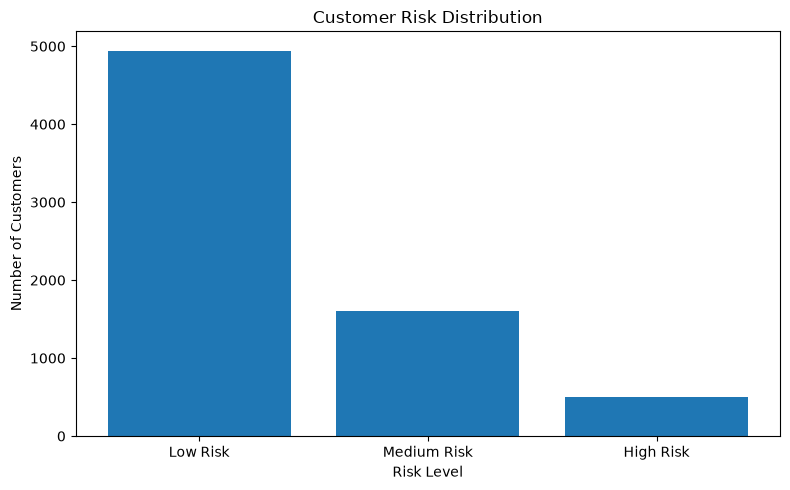

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    risk_summary["Risk Level"],
    risk_summary["Customer Count"]
)

plt.title("Customer Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## 📖 Business Insights

In [12]:
print("Business Insights")
print("-" * 60)

print(f"Total Customers : {len(df)}")

print(f"High Risk Customers   : {(df['Risk_Level'] == 'High Risk').sum()}")

print(f"Medium Risk Customers : {(df['Risk_Level'] == 'Medium Risk').sum()}")

print(f"Low Risk Customers    : {(df['Risk_Level'] == 'Low Risk').sum()}")

print("\nRecommendation:")

print("• Prioritize High Risk customers for immediate retention campaigns.")

print("• Offer personalized discounts or loyalty benefits to Medium Risk customers.")

print("• Continue maintaining satisfaction for Low Risk customers.")

Business Insights
------------------------------------------------------------
Total Customers : 7043
High Risk Customers   : 496
Medium Risk Customers : 1603
Low Risk Customers    : 4944

Recommendation:
• Prioritize High Risk customers for immediate retention campaigns.
• Offer personalized discounts or loyalty benefits to Medium Risk customers.
• Continue maintaining satisfaction for Low Risk customers.


## 💾 Export Customer Risk Scores

In [13]:
# Select important columns
customer_risk_scores = df[
    [
        "customer_id",
        "Predicted_Churn",
        "Churn_Probability",
        "Risk_Level"
    ]
]

customer_risk_scores.head()

,customer_id,Predicted_Churn,Churn_Probability,Risk_Level
0,7590-VHVEG,Yes,0.613717,Medium Risk
1,5575-GNVDE,No,0.044497,Low Risk
2,3668-QPYBK,No,0.299185,Low Risk
3,7795-CFOCW,No,0.028452,Low Risk
4,9237-HQITU,Yes,0.691580,Medium Risk


In [14]:
customer_risk_scores.to_csv(
    "../Dataset/Processed/customer_risk_scores.csv",
    index=False
)

print("✅ Customer Risk Scores exported successfully!")

✅ Customer Risk Scores exported successfully!
